In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import sys
sys.path.append('..')

from src.network import Network
from src.layers import Dense
from src.activations import ReLU, Softmax
from src.losses import CrossEntropyLoss

In [2]:
# Pobierz MNIST
print("Pobieranie MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

# Normalizacja 0-255 -> 0-1
X = X / 255.0

# One-hot encoding etykiet (0-9 -> wektor długości 10)
y_onehot = np.zeros((len(y), 10))
y_onehot[np.arange(len(y)), y] = 1

# Podział na train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Przyklad etykiety: {y_train[0]}")

Pobieranie MNIST...
Train: (56000, 784), Test: (14000, 784)
Przyklad etykiety: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


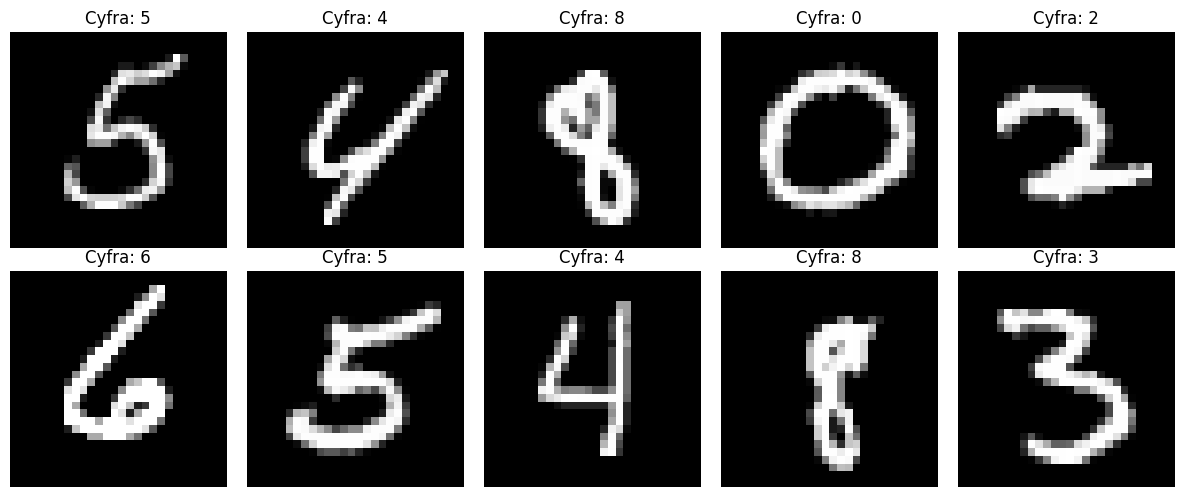

In [ ]:
# Podgląd kilku cyfr
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Cyfra: {np.argmax(y_train[i])}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Sprawdzamy co się dzieje w pierwszym forward passie
from src.layers import Dense
from src.activations import ReLU, Softmax

x_sample = X_train[:32]
print(f"Input:  min={x_sample.min():.4f} max={x_sample.max():.4f}")

d1 = Dense(784, 128)
out1 = d1.forward(x_sample)
print(f"Dense1: min={out1.min():.4f} max={out1.max():.4f}")

r1 = ReLU()
out2 = r1.forward(out1)
print(f"ReLU1:  min={out2.min():.4f} max={out2.max():.4f}")

d2 = Dense(128, 64)
out3 = d2.forward(out2)
print(f"Dense2: min={out3.min():.4f} max={out3.max():.4f}")

d3 = Dense(64, 10)
r2 = ReLU()
out4 = r2.forward(out3)
print(f"ReLU2:  min={out4.min():.4f} max={out4.max():.4f}")

out5 = d3.forward(out4)
print(f"Dense3: min={out5.min():.4f} max={out5.max():.4f}")

s1 = Softmax()
out6 = s1.forward(out5)
print(f"Softmax: min={out6.min():.4f} max={out6.max():.4f}")

# Sprawdź gradient
y_sample = y_train[:32]
grad = -y_sample / np.clip(out6, 1e-7, 1 - 1e-7) / len(y_sample)
print(f"Grad:   min={grad.min():.4f} max={grad.max():.4f}")

Input:  min=0.0000 max=1.0000
Dense1: min=-2.2446 max=2.0683
ReLU1:  min=0.0000 max=2.0683
Dense2: min=-1.7220 max=1.5976
ReLU2:  min=0.0000 max=1.5976
Dense3: min=-1.2629 max=1.3503
Softmax: min=0.0178 max=0.2802
Grad:   min=-1.0156 max=-0.0000


In [5]:
# Sprawdzamy backward pass krok po kroku
g3 = d3.backward(grad)
print(f"Grad po Dense3:  min={g3.min():.4f} max={g3.max():.4f}")

g2 = r2.backward(g3)
print(f"Grad po ReLU2:   min={g2.min():.4f} max={g2.max():.4f}")

g1 = d2.backward(g2)
print(f"Grad po Dense2:  min={g1.min():.4f} max={g1.max():.4f}")

gr1 = r1.backward(g1)
print(f"Grad po ReLU1:   min={gr1.min():.4f} max={gr1.max():.4f}")

gd1 = d1.backward(gr1)
print(f"Grad po Dense1:  min={gd1.min():.4f} max={gd1.max():.4f}")

print(f"\ndweights Dense3: min={d3.dweights.min():.4f} max={d3.dweights.max():.4f}")
print(f"dweights Dense2: min={d2.dweights.min():.4f} max={d2.dweights.max():.4f}")
print(f"dweights Dense1: min={d1.dweights.min():.4f} max={d1.dweights.max():.4f}")

NameError: name 'd3' is not defined

In [6]:
# Symulujemy jedną aktualizację
lr = 0.001
print(f"Wagi Dense1 przed: min={d1.weights.min():.4f} max={d1.weights.max():.4f}")
d1.weights -= lr * d1.dweights
print(f"Wagi Dense1 po:    min={d1.weights.min():.4f} max={d1.weights.max():.4f}")

print(f"Wagi Dense2 przed: min={d2.weights.min():.4f} max={d2.weights.max():.4f}")
d2.weights -= lr * d2.dweights
print(f"Wagi Dense2 po:    min={d2.weights.min():.4f} max={d2.weights.max():.4f}")

NameError: name 'd1' is not defined

In [ ]:
# Budujemy sieć
model = Network()
model.add(Dense(784, 128))
model.add(ReLU())
model.add(Dense(128, 64))
model.add(ReLU())
model.add(Dense(64, 10))
model.add(Softmax())

# Trening
model.train(X_train, y_train, epochs=100, lr=0.01, batch_size=32)

c:\Users\Michal\ai-projects\neural-network-from-scratch\notebooks\..\src\layers.py:11: RuntimeWarning: overflow encountered in dot
  return np.dot(x, self.weights) + self.biases
c:\Users\Michal\ai-projects\neural-network-from-scratch\notebooks\..\src\activations.py:21: RuntimeWarning: invalid value encountered in subtract
  exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))


Epoch   0 | loss: nan | acc: 0.0993
Epoch  10 | loss: nan | acc: 0.0993


KeyboardInterrupt: 